# Eigenfrequency Analysis

Computes natural frequencies of the moored tanker by scanning for sign changes in
$\det[C_{\rm tot} - \omega^2(M + A(\omega))]$ over the WAMIT frequency grid
(48 points, 0.30–2.65 rad/s) and an extrapolated low-frequency range for mooring
and fender modes.

In [ ]:
import os
import sys
from pathlib import Path

# Resolve this notebook's folder (works in VS Code and standard Jupyter)
NOTEBOOK_DIR = Path(globals().get('__vsc_ipynb_file__', Path.cwd() / '_')).parent
os.chdir(NOTEBOOK_DIR)
sys.path.insert(0, str(NOTEBOOK_DIR))
from thesis_style import apply, full, FULL_WIDTH, save
apply()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

WAMIT_ROOT = str(NOTEBOOK_DIR / "WAMIT_Results")

## Added Mass and Radiation Damping

In [2]:
AM_ENTRIES = [
    ("surge",        0, 0), ("surge_heave",  0, 2), ("surge_pitch",  0, 4),
    ("sway",         1, 1), ("sway_roll",    1, 3), ("sway_yaw",     1, 5),
    ("heave",        2, 2), ("heave_surge",  2, 0), ("heave_pitch",  2, 4),
    ("roll",         3, 3), ("roll_sway",    3, 1), ("roll_yaw",     3, 5),
    ("pitch",        4, 4), ("pitch_surge",  4, 0), ("pitch_heave",  4, 2),
    ("yaw",          5, 5), ("yaw_sway",     5, 1), ("yaw_roll",     5, 3),
]

_ref  = pd.read_csv(os.path.join(WAMIT_ROOT, "AddedMass", "Added mass 1_surge.csv"),
                    sep=";", skiprows=1)
omega = _ref.iloc[:, 0].to_numpy()
N     = len(omega)

A_tensor = np.zeros((N, 6, 6))
B_tensor = np.zeros((N, 6, 6))
A0_mat   = np.zeros((6, 6))   # zero-frequency added mass from WAMIT (col 5, row 0)

for suffix, i, j in AM_ENTRIES:
    df_a = pd.read_csv(
        os.path.join(WAMIT_ROOT, "AddedMass", f"Added mass 1_{suffix}.csv"),
        sep=";", skiprows=1)
    df_b = pd.read_csv(
        os.path.join(WAMIT_ROOT, "Damping", f"Radiation damping 1_{suffix}.csv"),
        sep=";", skiprows=1)
    A_tensor[:, i, j] = df_a.iloc[:, 1].to_numpy()
    B_tensor[:, i, j] = df_b.iloc[:, 1].to_numpy()
    val = df_a.iloc[0, 5]
    if pd.notna(val):
        A0_mat[i, j] = float(val)

print(f"Frequency range: {omega[0]:.3f} – {omega[-1]:.3f} rad/s  ({N} points)")

Frequency range: 0.300 – 2.650 rad/s  (48 points)


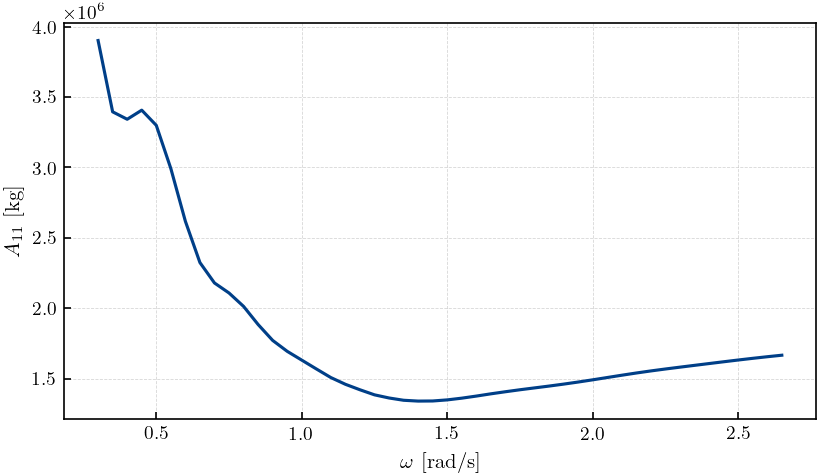

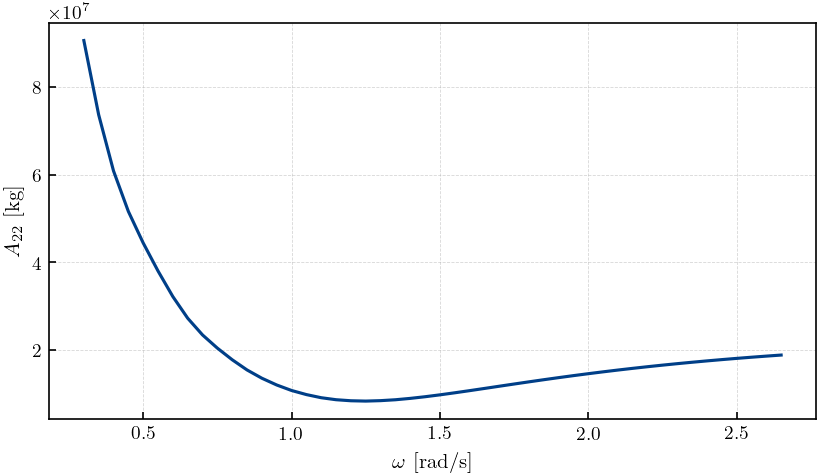

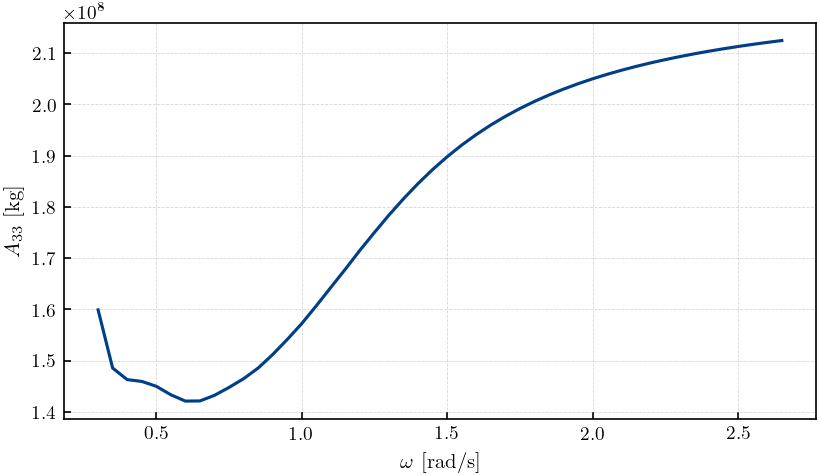

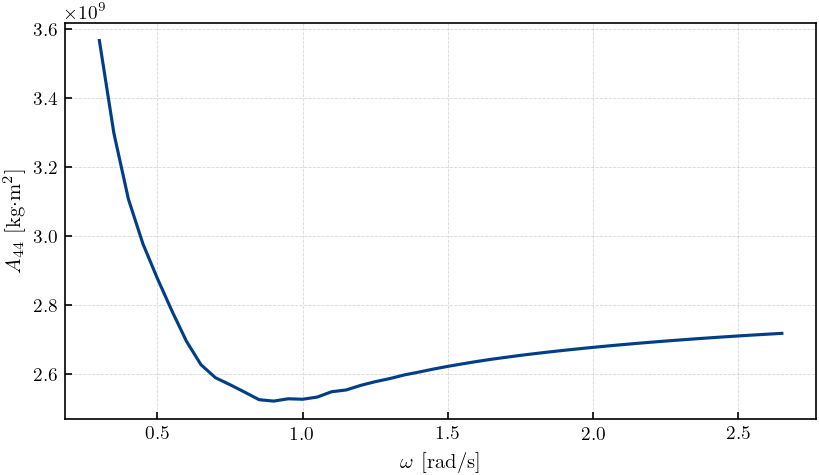

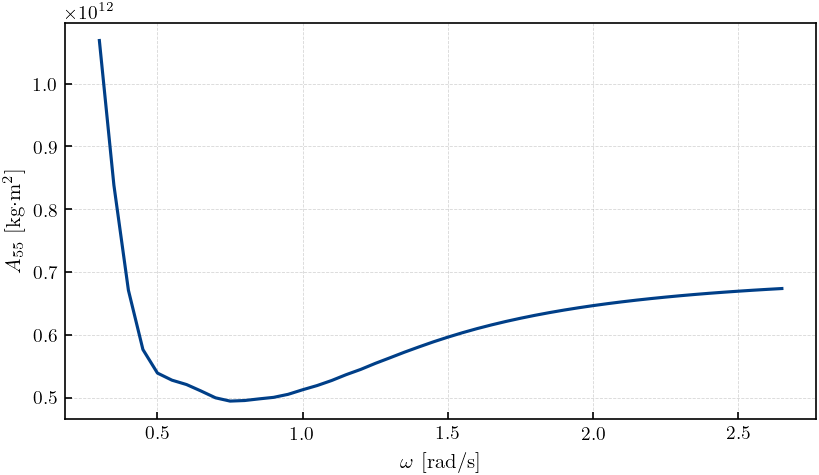

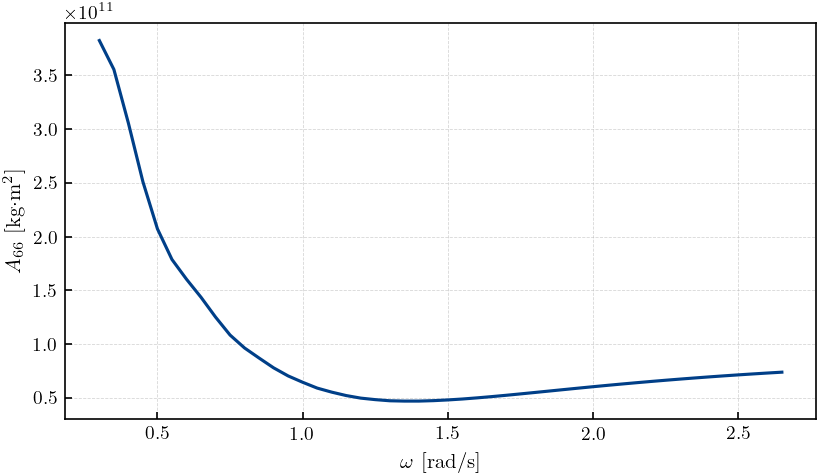

In [3]:
DOF_LABELS = ["Surge", "Sway", "Heave", "Roll", "Pitch", "Yaw"]
A_UNITS    = ["kg", "kg", "kg",
               r"kg$\cdot$m$^2$", r"kg$\cdot$m$^2$", r"kg$\cdot$m$^2$"]
A_SUBS     = ["11", "22", "33", "44", "55", "66"]

for j, (name, unit, sub) in enumerate(zip(DOF_LABELS, A_UNITS, A_SUBS)):
    fig, ax = plt.subplots(figsize=full())
    ax.plot(omega, A_tensor[:, j, j], color="#003f88")
    ax.set_xlabel(r"$\omega$ [rad/s]")
    ax.set_ylabel(f"$A_{{{sub}}}$ [{unit}]")
    plt.tight_layout()
    save(fig, f"AM_{name.lower()}")
    plt.show()

## Radiation Damping – Diagonal Coefficients

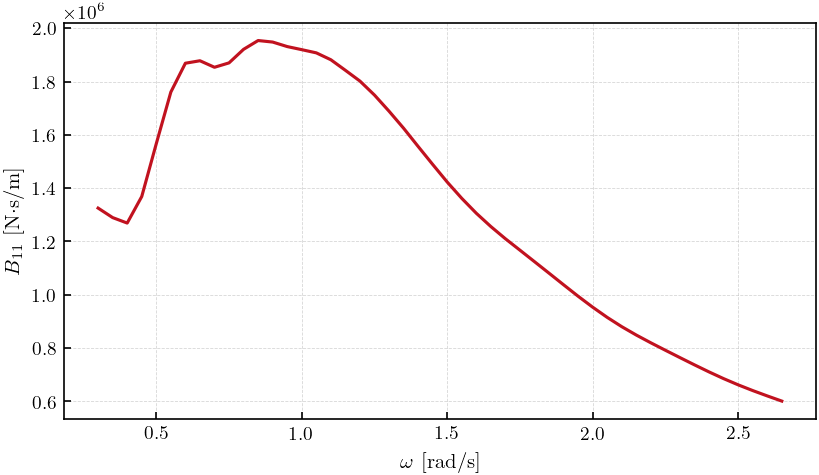

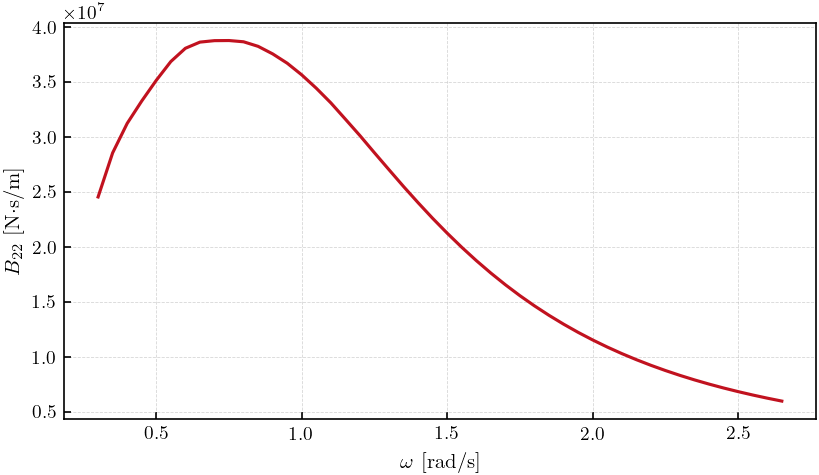

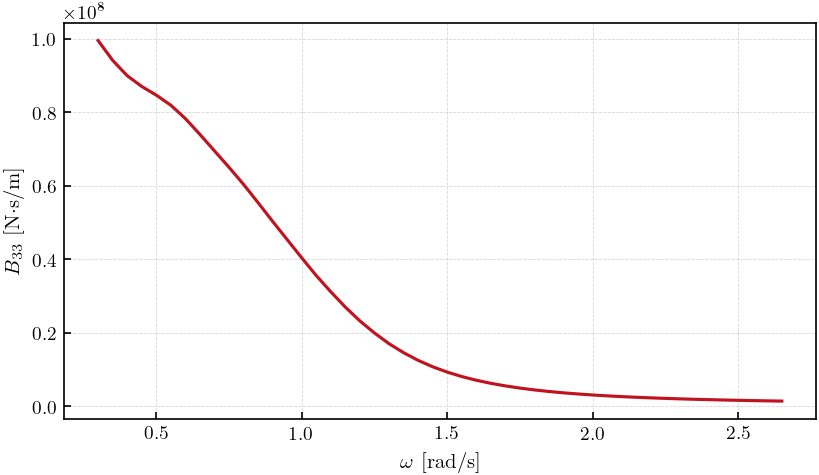

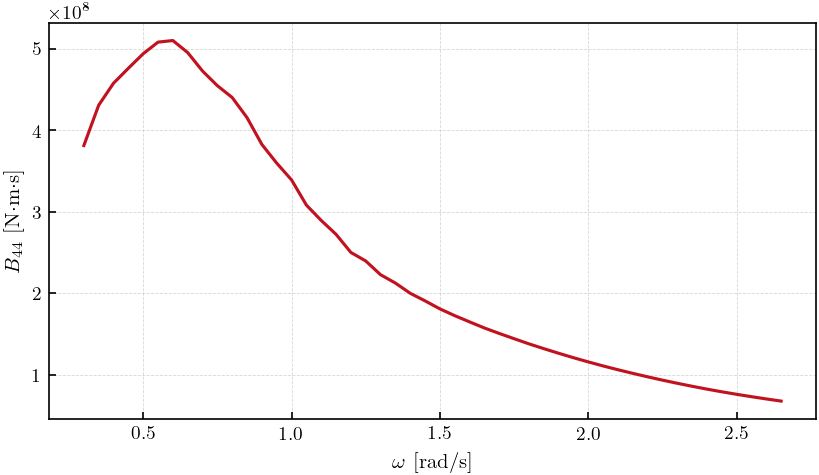

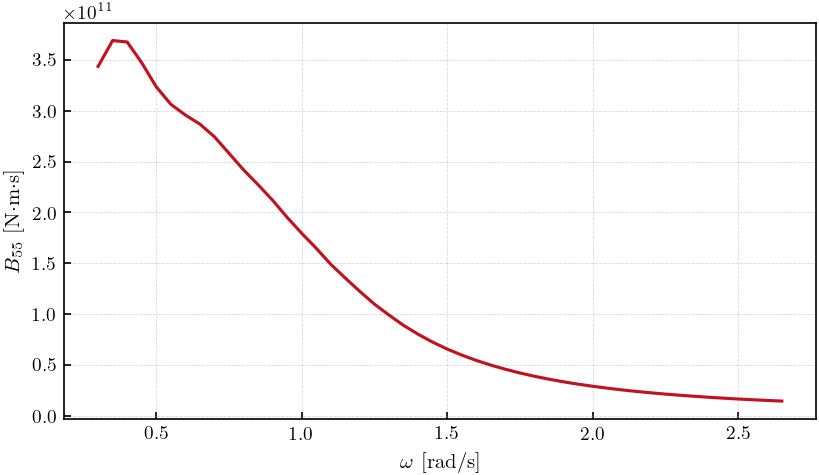

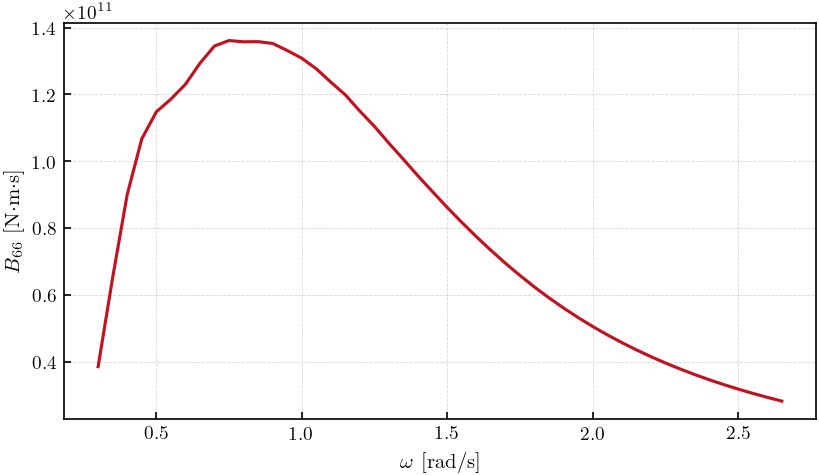

In [4]:
B_UNITS = [r"N$\cdot$s/m", r"N$\cdot$s/m", r"N$\cdot$s/m",
           r"N$\cdot$m$\cdot$s", r"N$\cdot$m$\cdot$s", r"N$\cdot$m$\cdot$s"]

for j, (name, unit, sub) in enumerate(zip(DOF_LABELS, B_UNITS, A_SUBS)):
    fig, ax = plt.subplots(figsize=full())
    ax.plot(omega, B_tensor[:, j, j], color="#c1121f")
    ax.set_xlabel(r"$\omega$ [rad/s]")
    ax.set_ylabel(f"$B_{{{sub}}}$ [{unit}]")
    plt.tight_layout()
    save(fig, f"B_{name.lower()}")
    plt.show()

## Structural Matrices

Mass matrix, hydrostatic stiffness, mooring stiffness, and linearised fender stiffness.

In [5]:
# Hydrostatic stiffness
C_hs = np.array([[0, 0,    0,     0,      0,      0],
                 [0, 0,    0,     0,      0,      0],
                 [0, 0,  8.2e7,   0,    8.9e8,    0],
                 [0, 0,    0,   4.0e9,    0,      0],
                 [0, 0,  8.9e8,   0,   3.6e11,    0],
                 [0, 0,    0,     0,      0,      0]])

# Mooring stiffness
C_moor = np.array([
    [ 4.33903e+05, -7.49583e+03,  3.74792e+03,  1.12437e+05,  1.09746e+06, -2.52720e+06],
    [-7.49583e+03,  7.05115e+05, -8.78774e+04, -5.30908e+06, -2.37827e+05, -1.59016e+06],
    [ 3.74792e+03, -8.78774e+04,  2.48229e+04,  8.44792e+05,  3.02761e+04,  1.25389e+05],
    [ 1.12437e+05, -5.30908e+06,  8.44792e+05,  4.40404e+07,  1.94995e+06,  1.17124e+07],
    [ 1.09746e+06, -2.37827e+05,  3.02761e+04,  1.94995e+06,  2.34569e+08,  9.56906e+08],
    [-2.52720e+06, -1.59016e+06,  1.25389e+05,  1.17124e+07,  9.56906e+08,  8.46265e+09],
])


# Vessel inertia
rho    = 1025.0
V_ship = 82520.1
m      = rho * V_ship
L_ship = 250.0
B_ship = 36.0
cg     = [-4.8, 0.0, 3.0]

k_phi   = 0.35 * B_ship
k_theta = 0.25 * L_ship
k_psi   = 0.25 * L_ship

Mzg = m * cg[2]
I4  = m * k_phi**2
I46 = m * cg[0] * cg[2]
I5  = m * k_theta**2
I6  = m * k_psi**2

M_mat = np.array([
    [m,    0,    0,     0,   Mzg,    0 ],
    [0,    m,    0,  -Mzg,    0,     0 ],
    [0,    0,    m,     0,    0,     0 ],
    [0,  -Mzg,  0,    I4,    0,   -I46],
    [Mzg,  0,   0,     0,   I5,     0 ],
    [0,    0,   0,  -I46,    0,    I6 ],
])

print(f"Mass: {m:.4e} kg")

Mass: 8.4583e+07 kg


## Fender Stiffness

In [6]:
fender_dist  = np.array([0.0, -0.25, -0.5, -0.75, -0.95, -1.05,
                         -1.25, -1.5, -1.75, -1.95, -2.05, -2.25, -2.5])
fender_force = np.array([0.0, 8.1818e5, 1.2424e6, 1.3939e6, 1.272e6, 1.272e6,
                         1.6205e6, 2.0e6, 1.9303e6, 1.8083e6, 1.8083e6,
                         2.8227e6, 5.053e6])

n_fenders    = 6
delta_single = 0.03            # compression per fender [m]
delta_op     = delta_single    # operating deflection per fender [m]
F_op         = np.interp(delta_op, np.abs(fender_dist), fender_force)
k_fender     = F_op / delta_op

x_arms   = [10.0, 30.0, 50.0]
C_fender = np.zeros((6, 6))
C_fender[1, 1] = n_fenders * k_fender
C_fender[5, 5] = 2 * k_fender * sum(x**2 for x in x_arms)

C_tot = C_hs + C_moor + C_fender

print(f"Fender stiffness: {k_fender:.4e} N/m")

Fender stiffness: 3.2727e+06 N/m


## Eigenfrequency Scan

Eigenfrequencies are found as sign changes in $\det[C_{\rm tot} - \omega^2(M+A(\omega))]$.
The WAMIT grid (0.30–2.65 rad/s) covers heave and higher modes.  Below 0.30 rad/s,
$A(\omega)$ is extended using a Hermite cubic anchored at the WAMIT zero-frequency value
$A_0$ (flat slope) and matching the tangent of the WAMIT data at $\omega = 0.30$ rad/s.

In [7]:
# Hermite cubic extrapolation of A(omega) below the WAMIT range.
# p(0)=A0, p'(0)=0 (flat at zero freq), p(h)=A(h), p'(h)=tangent from WAMIT data.
h         = omega[0]                                          # 0.30 rad/s
dA        = (A_tensor[1] - A_tensor[0]) / (omega[1] - omega[0])  # tangent at h
omega_low = np.arange(0.0, h, 0.005)

A_low = np.zeros((len(omega_low), 6, 6))
for i in range(6):
    for j in range(6):
        A_h = A_tensor[0, i, j]
        A_0 = A0_mat[i, j]
        s   = dA[i, j]
        # p(w) = A_0 + c*w^2 + d*w^3  (b=0 enforces p'(0)=0)
        mat      = np.array([[h**2, h**3], [2*h, 3*h**2]])
        c, d     = np.linalg.solve(mat, [A_h - A_0, s])
        A_low[:, i, j] = A_0 + c*omega_low**2 + d*omega_low**3

omega_full = np.concatenate([omega_low, omega])
A_full     = np.concatenate([A_low, A_tensor], axis=0)

# sign(det) for C_hs only and C_tot over the full frequency range
sign_hs  = np.array([
    np.linalg.slogdet(C_hs  - w**2 * (M_mat + A_full[k]))[0]
    for k, w in enumerate(omega_full)
])
sign_tot = np.array([
    np.linalg.slogdet(C_tot - w**2 * (M_mat + A_full[k]))[0]
    for k, w in enumerate(omega_full)
])

def find_eigen(omegas, signs):
    return [0.5*(omegas[i-1]+omegas[i]) for i in range(1, len(omegas))
            if signs[i-1]*signs[i] < 0]

eigen_hs  = find_eigen(omega_full, sign_hs)
eigen_tot = find_eigen(omega_full, sign_tot)

print("C_hs only:")
for w in eigen_hs:
    print(f"  ω = {w:.4f} rad/s   T = {2*np.pi/w:.2f} s")
print("\nC_tot (C_hs + C_moor + C_fender):")
for w in eigen_tot:
    print(f"  ω = {w:.4f} rad/s   T = {2*np.pi/w:.2f} s")

C_hs only:
  ω = 0.5250 rad/s   T = 11.97 s
  ω = 0.5750 rad/s   T = 10.93 s
  ω = 0.6750 rad/s   T = 9.31 s

C_tot (C_hs + C_moor + C_fender):
  ω = 0.0675 rad/s   T = 93.08 s
  ω = 0.1975 rad/s   T = 31.81 s
  ω = 0.3250 rad/s   T = 19.33 s
  ω = 0.5250 rad/s   T = 11.97 s
  ω = 0.5750 rad/s   T = 10.93 s
  ω = 0.6750 rad/s   T = 9.31 s


### Added Mass – WAMIT Data with Hermite Extrapolation

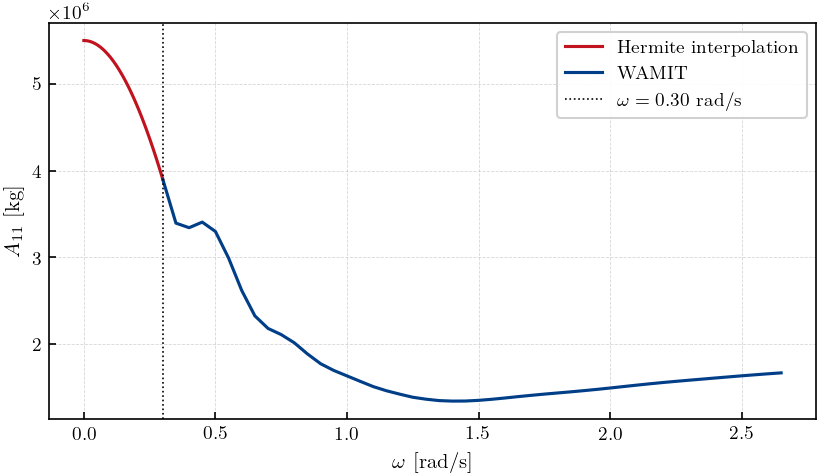

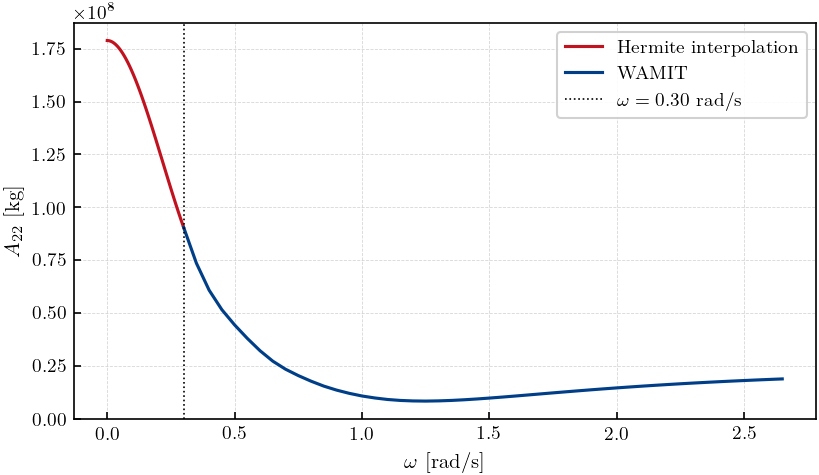

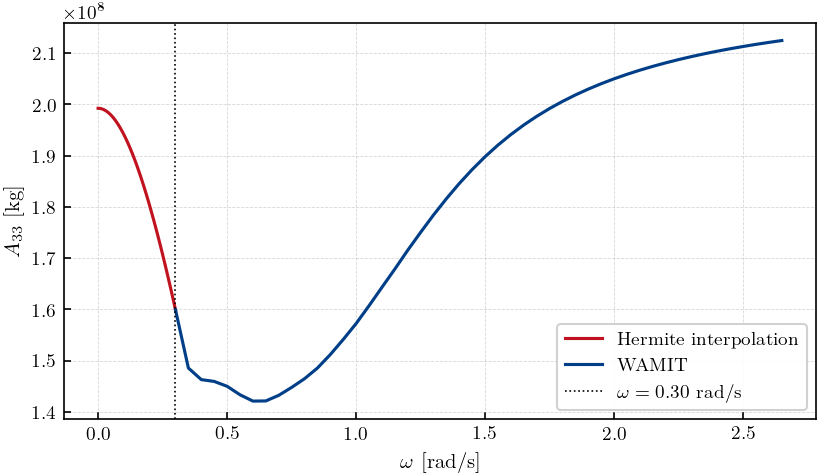

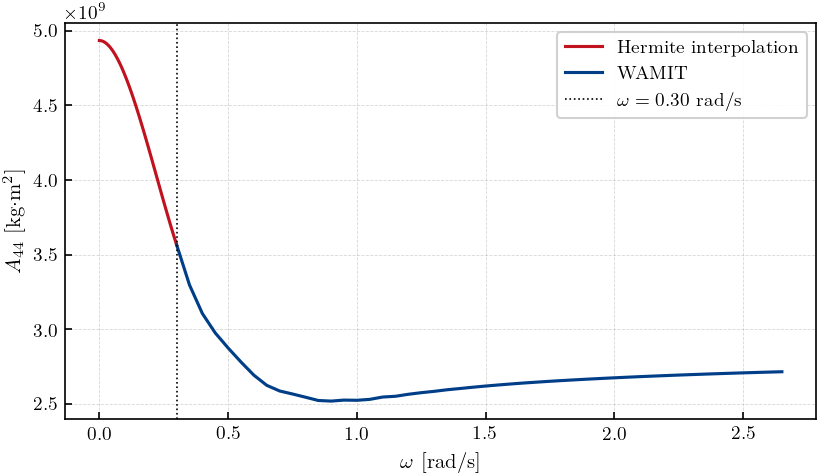

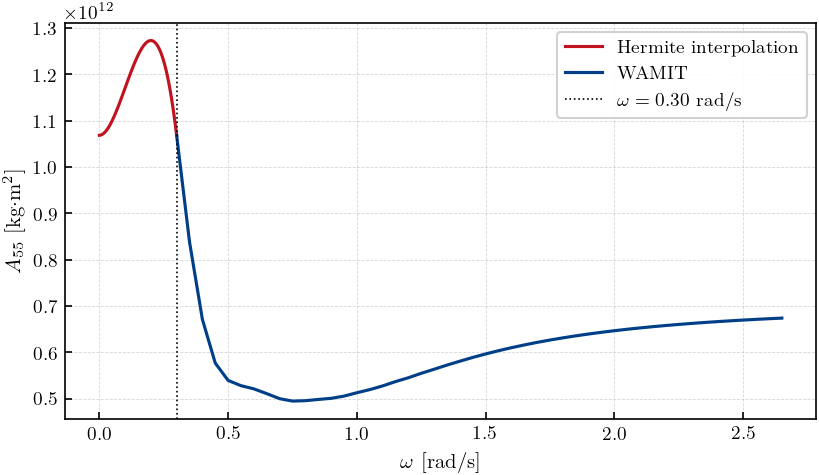

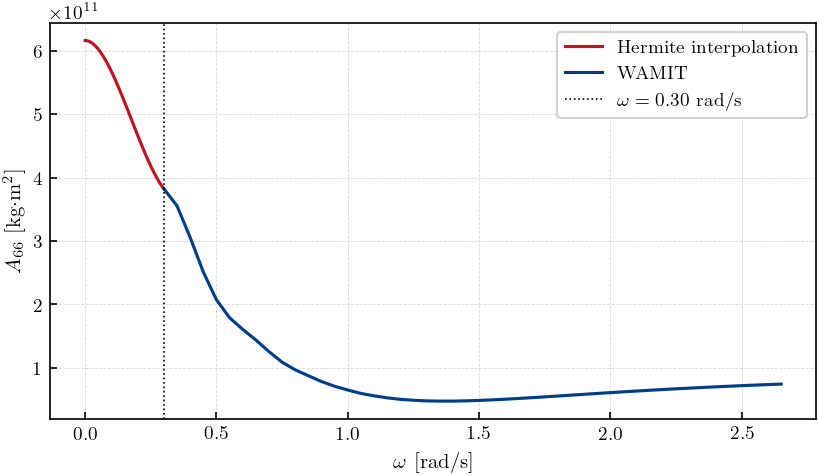

In [12]:
n_extrap = len(omega_low)

for j, (name, unit, sub) in enumerate(zip(DOF_LABELS, A_UNITS, A_SUBS)):
    fig, ax = plt.subplots(figsize=full())
    ax.plot(omega_low, A_full[:n_extrap, j, j], color="#c1121f", lw=1.5,
            label="Hermite interpolation")
    ax.plot(omega,     A_tensor[:, j, j],        color="#003f88", lw=1.5,
            label="WAMIT")
    ax.axvline(h, color="k", lw=0.8, ls=":", label=r"$\omega = 0.30$ rad/s")
    ax.set_xlabel(r"$\omega$ [rad/s]")
    ax.set_ylabel(f"$A_{{{sub}}}$ [{unit}]")
    ax.legend()
    plt.tight_layout()
    save(fig, f"AM_{name.lower()}_extrap")
    plt.show()

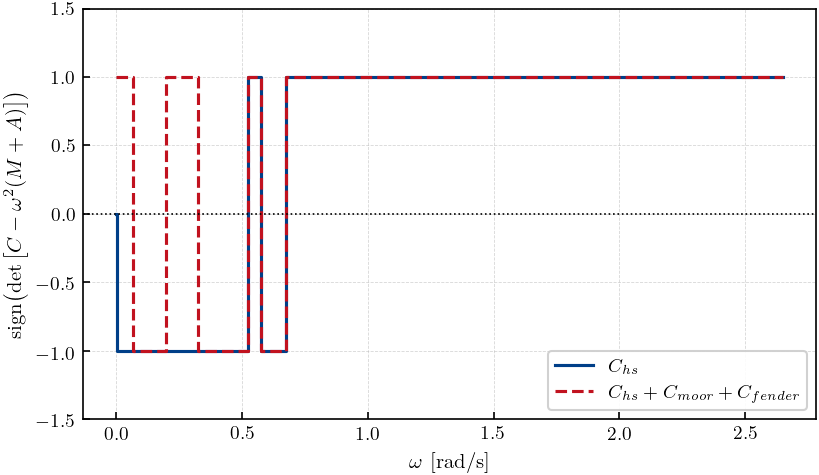

In [9]:
fig, ax = plt.subplots(figsize=full())
ax.step(omega_full, sign_hs,  where="mid", color="#003f88", lw=1.5, label=r"$C_{hs}$")
ax.step(omega_full, sign_tot, where="mid", color="#c1121f", lw=1.5, ls="--",
        label=r"$C_{hs} + C_{moor} + C_{fender}$")
ax.axhline(0, color="k", lw=0.8, ls=":")
ax.set_xlabel(r"$\omega$ [rad/s]")
ax.set_ylabel(r"sign$\left(\det\left[C - \omega^2(M+A)\right]\right)$")
ax.set_ylim([-1.5, 1.5])
ax.legend(loc="lower right")
plt.tight_layout()
save(fig, "eigenfreq_scan")
plt.show()

In [10]:
DOF_NAMES_LOWER = ["surge", "sway", "heave", "roll", "pitch", "yaw"]

print(f"{'='*60}")
print("Mode shapes at natural frequencies  (C_hs only)")
print(f"{'='*60}")
for w_est in eigen_hs:
    idx          = np.argmin(np.abs(omega_full - w_est))
    MA           = M_mat + A_full[idx]
    K            = np.linalg.solve(MA, C_hs)
    D            = K - w_est**2 * np.eye(6)
    evals, evecs = np.linalg.eig(D)
    i_min        = np.argmin(np.abs(evals))
    ev           = np.real(evecs[:, i_min])
    ev          /= np.max(np.abs(ev))
    print(f"\n  ω = {w_est:.4f} rad/s   T = {2*np.pi/w_est:.2f} s")
    print(f"  Eigenvalue: {evals[i_min]:.4e}")
    print(f"  Mode shape (normalised):")
    for dof, val in zip(DOF_NAMES_LOWER, ev):
        print(f"    {dof:>6s}: {val:+.4f}")

Mode shapes at natural frequencies  (C_hs only)

  ω = 0.5250 rad/s   T = 11.97 s
  Eigenvalue: -1.0596e-02
  Mode shape (normalised):
     surge: +0.0000
      sway: +1.0000
     heave: +0.0000
      roll: +0.3314
     pitch: +0.0000
       yaw: -0.0030

  ω = 0.5750 rad/s   T = 10.93 s
  Eigenvalue: 1.8653e-02
  Mode shape (normalised):
     surge: +0.0324
      sway: +0.0000
     heave: +1.0000
      roll: +0.0000
     pitch: -0.0066
       yaw: +0.0000

  ω = 0.6750 rad/s   T = 9.31 s
  Eigenvalue: -1.1816e-02
  Mode shape (normalised):
     surge: -0.6031
      sway: +0.0000
     heave: +1.0000
      roll: +0.0000
     pitch: +0.0608
       yaw: +0.0000


In [11]:
DOF_NAMES_LOWER = ["surge", "sway", "heave", "roll", "pitch", "yaw"]

print(f"{'='*60}")
print("Mode shapes at natural frequencies  (C_tot)")
print(f"{'='*60}")
for w_est in eigen_tot:
    idx          = np.argmin(np.abs(omega_full - w_est))
    MA           = M_mat + A_full[idx]
    K            = np.linalg.solve(MA, C_tot)
    D            = K - w_est**2 * np.eye(6)
    evals, evecs = np.linalg.eig(D)
    i_min        = np.argmin(np.abs(evals))
    ev           = np.real(evecs[:, i_min])
    ev          /= np.max(np.abs(ev))
    print(f"\n  ω = {w_est:.4f} rad/s   T = {2*np.pi/w_est:.2f} s")
    print(f"  Eigenvalue: {evals[i_min]:.4e}")
    print(f"  Mode shape (normalised):")
    for dof, val in zip(DOF_NAMES_LOWER, ev):
        print(f"    {dof:>6s}: {val:+.4f}")

Mode shapes at natural frequencies  (C_tot)

  ω = 0.0675 rad/s   T = 93.08 s
  Eigenvalue: 2.6067e-04
  Mode shape (normalised):
     surge: -1.0000
      sway: -0.0004
     heave: -0.0000
      roll: +0.0000
     pitch: -0.0000
       yaw: -0.0001

  ω = 0.1975 rad/s   T = 31.81 s
  Eigenvalue: 2.7806e-05
  Mode shape (normalised):
     surge: +0.7442
      sway: +0.0987
     heave: -0.0354
      roll: -0.1041
     pitch: +0.0035
       yaw: -1.0000

  ω = 0.3250 rad/s   T = 19.33 s
  Eigenvalue: 2.4903e-03
  Mode shape (normalised):
     surge: -0.0012
      sway: +1.0000
     heave: +0.0021
      roll: -0.0252
     pitch: -0.0000
       yaw: +0.0004

  ω = 0.5250 rad/s   T = 11.97 s
  Eigenvalue: 1.4858e-02
  Mode shape (normalised):
     surge: -0.0004
      sway: -1.0000
     heave: +0.0041
      roll: -0.1588
     pitch: -0.0000
       yaw: +0.0019

  ω = 0.5750 rad/s   T = 10.93 s
  Eigenvalue: 1.8798e-02
  Mode shape (normalised):
     surge: +0.0326
      sway: -0.0016
     h